# Heart Disease Prediction Using Logistic Regression

## Overview

The goal of this project is to analyze clinical and demographic factors associated with heart disease and develop a predictive model using Logistic Regression.

The project includes:

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Correlation analysis
- Logistic Regression modeling
- Model evaluation using classification metrics
- ROC-AUC analysis
- Probability calibration assessment

The target variable (`target`) indicates whether a patient has heart disease:

- 0 = No Heart Disease
- 1 = Heart Disease

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve

In [2]:
# load the dataset
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.shape
df.info()
df.describe().T
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

## Data Exploration

Before building a predictive model, it is important to understand the structure and quality of the dataset.

In this section, we:

- Examine the dataset dimensions
- Review data types
- Generate descriptive statistics
- Identify missing values and duplicate records

This helps ensure the data is suitable for analysis and modeling.

In [4]:
# Checking for missing values and duplicates 
df.isnull().sum()
df.duplicated().sum()

1

In [5]:
df = df.drop_duplicates()
df.shape

(302, 14)

## Data Cleaning

Data quality directly impacts model performance.

The following checks were performed:

1. Missing value detection
2. Duplicate record identification
3. Removal of duplicate observations

Removing duplicate records prevents the model from learning repeated patterns that could bias predictions.

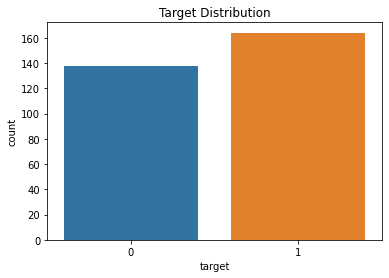

In [6]:
# understanding the target variable distribution
df['target'].value_counts()
df['target'].value_counts(normalize=True)
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

## Target Variable Distribution

Understanding the distribution of the target variable is essential before training a classification model.

A balanced dataset generally leads to more reliable performance metrics, while an imbalanced dataset may require specialized evaluation techniques or resampling methods.

The following visualization shows the proportion of patients with and without heart disease.

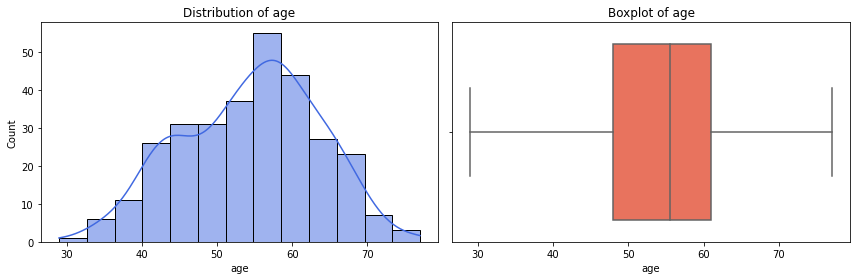

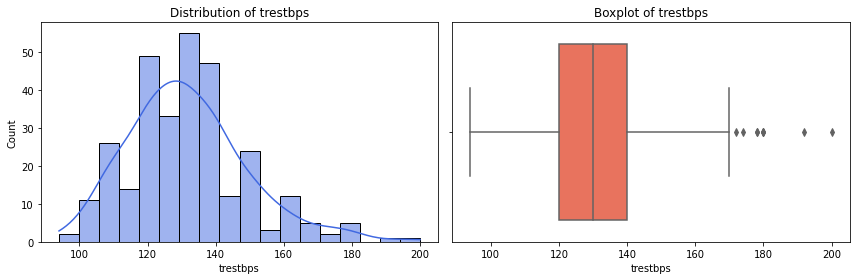

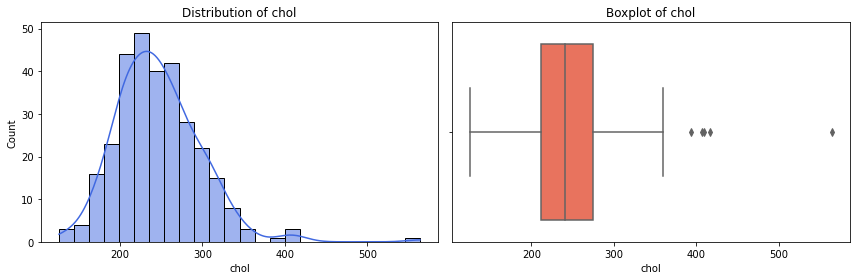

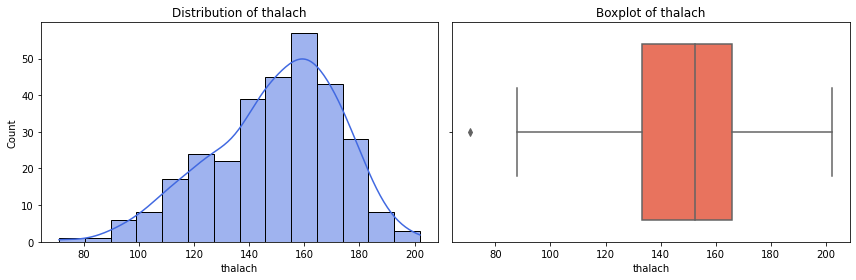

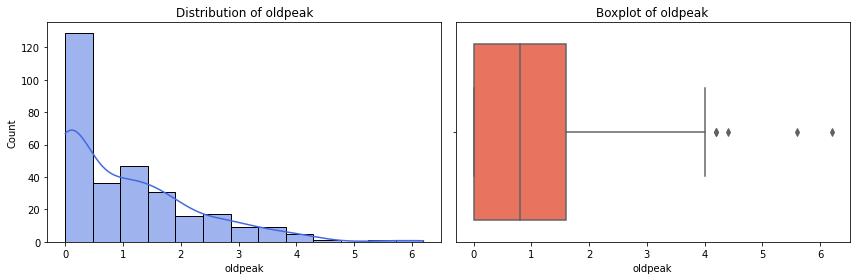

In [7]:
# univariate analysis of continuous features


categorical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

    # univariate analysis of continuous features

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in continuous_cols:
    plt.figure(figsize=(12, 4))
    
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color="royalblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color="tomato")
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()


## Univariate Analysis

Univariate analysis examines each feature individually to better understand its distribution.

For continuous variables, we use:

- Histograms to visualize distributions
- Kernel Density Estimates (KDE) to identify underlying patterns
- Boxplots to detect potential outliers

This analysis helps identify skewness, unusual observations, and data quality issues that may influence model performance.

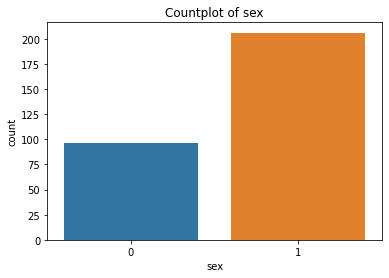

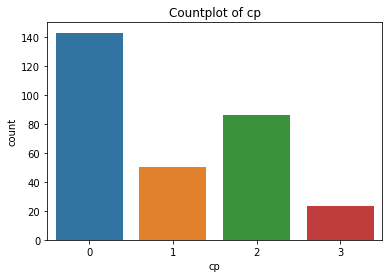

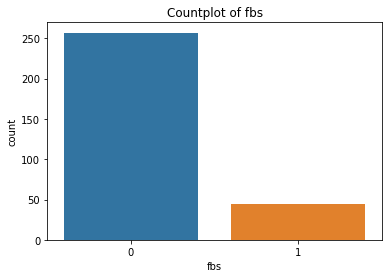

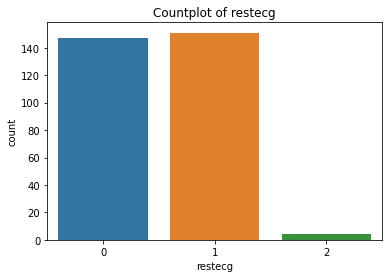

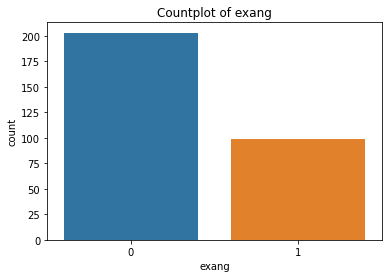

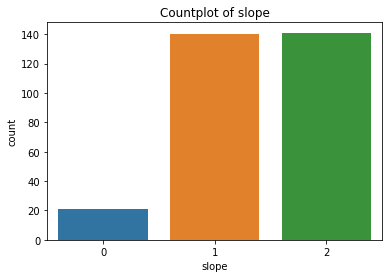

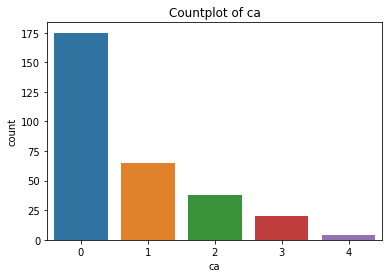

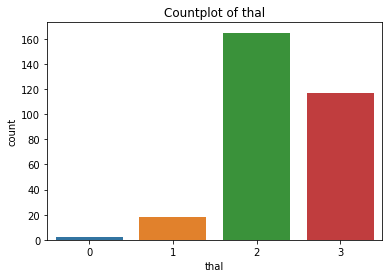

In [8]:
# plot countplots for categorical features

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot of {col}")
    plt.show()


## Categorical Feature Analysis

Categorical variables represent discrete groups or categories.

Countplots are used to examine:

- Frequency distributions
- Class imbalance within features
- Potentially dominant categories

Understanding these patterns helps identify variables that may strongly influence heart disease outcomes.

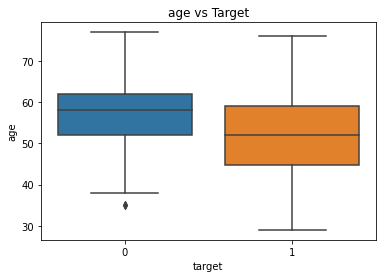

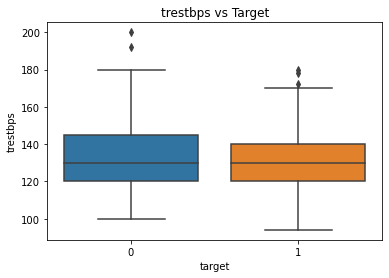

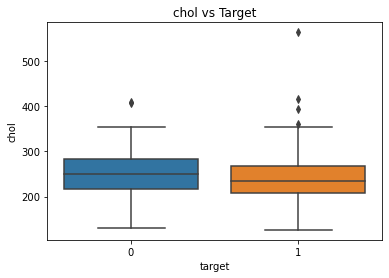

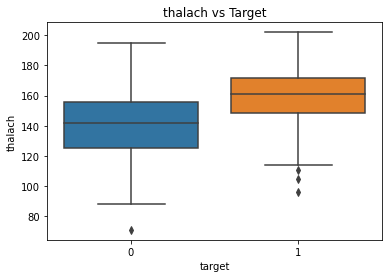

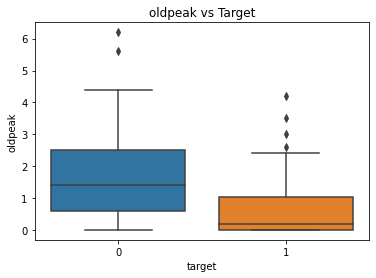

In [9]:
# bivariate analysis of continuous features with respect to the target variable

# continuous vs target

for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

## Relationship Between Features and Heart Disease

Bivariate analysis explores how individual features relate to the target variable.

For continuous variables, boxplots allow us to compare feature distributions between patients with and without heart disease.

Features showing clear separation between groups may be strong predictors in the classification model.

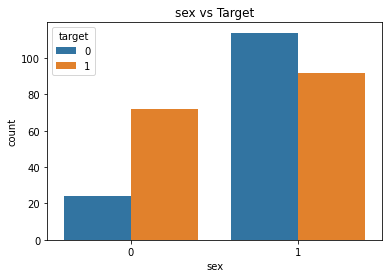

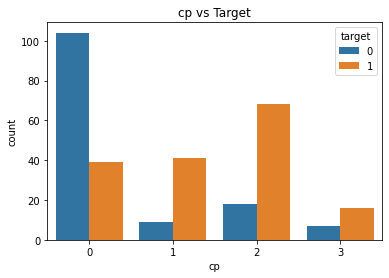

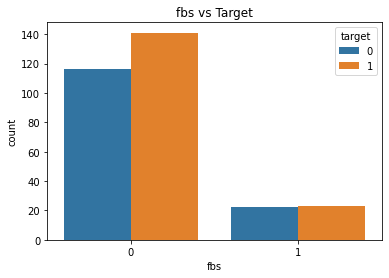

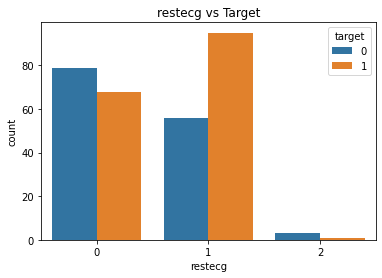

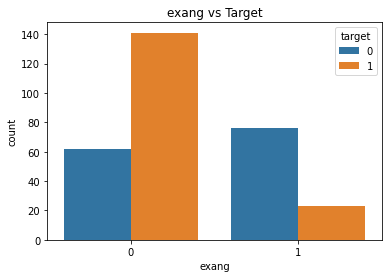

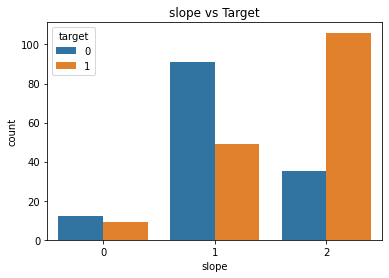

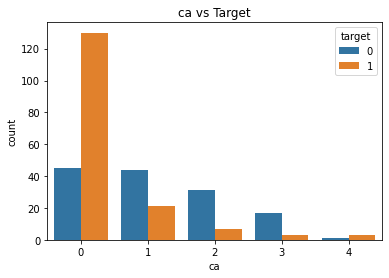

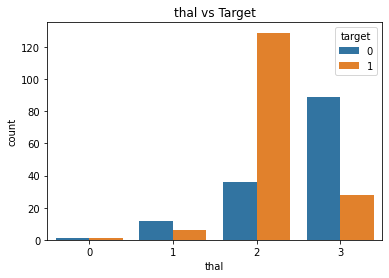

In [10]:
# categorical vs target

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='target', data=df)
    plt.title(f"{col} vs Target")
    plt.show()


## Categorical Features vs Heart Disease

This analysis examines how categorical variables differ between patients with and without heart disease.

Strong differences in category frequencies may indicate meaningful relationships with disease status and provide insight into important risk factors.

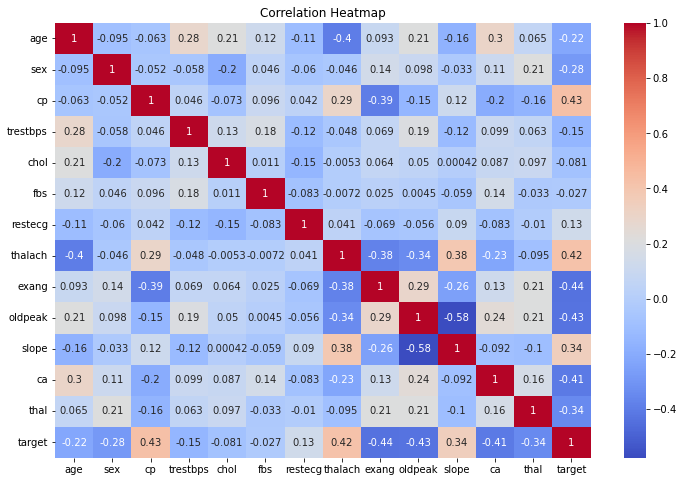

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# correlation heatmap of continuous features only

## Correlation Analysis

Correlation analysis helps identify relationships between variables.

The heatmap allows us to:

- Detect highly correlated predictors
- Identify features associated with heart disease
- Explore potential multicollinearity issues

Strong positive or negative correlations with the target variable suggest features that may contribute significantly to prediction performance.

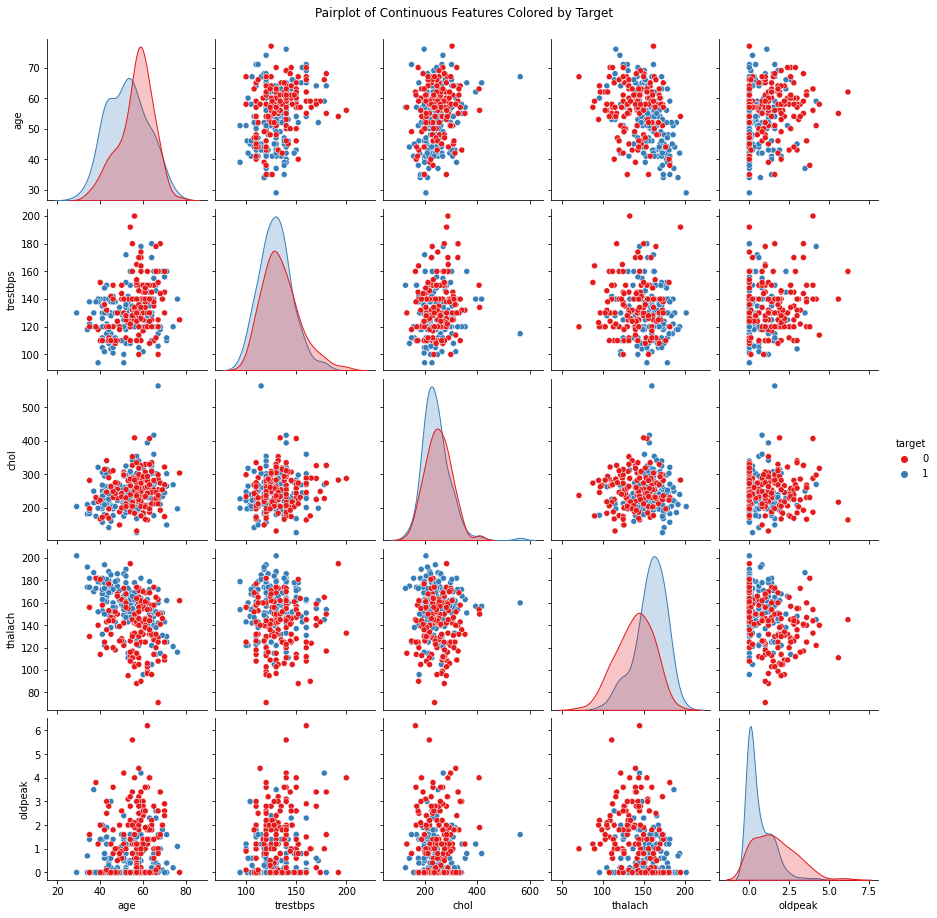

In [12]:
# pairplot of continuous features colored by target variable
sns.pairplot(df, vars=continuous_cols, hue='target', palette='Set1')
plt.suptitle("Pairplot of Continuous Features Colored by Target", y=1.02)
plt.show()

## Multivariate Visualization

Pairplots provide a visual representation of relationships among continuous variables.

By coloring observations according to the target variable, we can evaluate:

- Potential class separation
- Nonlinear relationships
- Feature interactions

These visual patterns help determine whether a linear model such as Logistic Regression is appropriate.

In [13]:
# logistic regression model 


X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale continuous features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
# fit a logistic regression model


log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

## Logistic Regression Model

Logistic Regression is a widely used classification algorithm that estimates the probability of an event occurring.

In this project, Logistic Regression is used to predict whether a patient has heart disease based on clinical characteristics.

The modeling process includes:

1. Feature-target separation
2. Train-test splitting
3. Feature standardization
4. Model training
5. Performance evaluation

In [15]:
# evaluate the model for accuracy and classification report

y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7868852459016393
              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61



In [16]:
# probability predictions (for calibration later)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_proba[:10]

array([0.07706101, 0.18700243, 0.00586341, 0.68915649, 0.69799016,
       0.03496338, 0.96610455, 0.12361334, 0.97227352, 0.73687016])

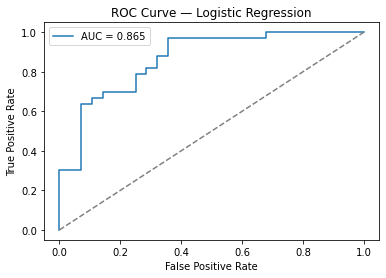

In [17]:
# ROC Curve and AUC


fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()


## ROC Curve and AUC

The Receiver Operating Characteristic (ROC) Curve evaluates the model's ability to distinguish between classes across different classification thresholds.

The Area Under the Curve (AUC) summarizes this performance:

- 0.5 = No discrimination
- 0.7–0.8 = Acceptable
- 0.8–0.9 = Excellent
- >0.9 = Outstanding

Higher AUC values indicate better classification performance.

In [18]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df


,feature,coefficient
2,cp,0.952331
7,thalach,0.579053
6,restecg,0.263408
10,slope,0.230875
0,age,0.030360
5,fbs,-0.054464
3,trestbps,-0.258203
4,chol,-0.454237
8,exang,-0.464419
11,ca,-0.556723


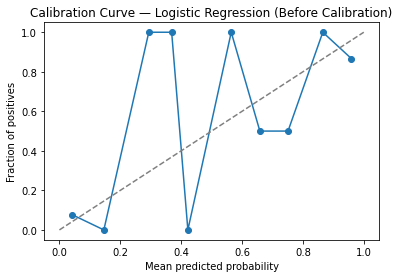

In [19]:
# calibration curve (before calibration)

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve — Logistic Regression (Before Calibration)")
plt.show()


In [20]:
# Brier Score (before calibration)

from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_proba)
brier


0.14390884472348942

## Probability Calibration

A classification model should not only predict classes correctly but also provide reliable probability estimates.

The calibration curve compares:

- Predicted probabilities
- Observed frequencies

A perfectly calibrated model follows the diagonal reference line.

Models with good calibration produce probabilities that closely reflect actual risk.

# Conclusion

This analysis explored the relationship between clinical characteristics and heart disease using Logistic Regression.

Key findings include:

- Several features showed meaningful relationships with heart disease status.
- Logistic Regression achieved strong classification performance.
- ROC-AUC analysis demonstrated the model's ability to distinguish between patients with and without heart disease.
- Calibration analysis provided insight into the reliability of predicted probabilities.

Overall, the model demonstrates that patient demographic and clinical measurements can be effectively used to predict heart disease risk and support data-driven healthcare decision-making.